# Advanced Banking Intent Classification

## Objective

Build high-performance NLP models for banking intent classification using:
- TF-IDF features
- Character n-grams
- LinearSVC optimization
- Ensemble learning
- Hyperparameter tuning

## Goal

Predict banking intent categories from user questions with maximum possible accuracy.

## Intent Categories

- Basic Accounts
- Digital Banking
- Loans & Interest
- Operations & Security
- General Finance
- Customer Service
- Financial Markets
- Insurance & Govt Schemes
- International Banking
- Banking Terminology

### Import Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Model loading/saving
import pickle

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

from xgboost import XGBClassifier

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


### Load Preprocessed Data

In [3]:
df = pd.read_csv("../data/processed_data/02_banking_processed.csv")

print("Dataset Shape:", df.shape)

df.sample(2)

Dataset Shape: (2331, 9)


,Category,Question,Answer,question_length,answer_length,clean_question,standard_category,processed_question,label
1857,Customer Service,How do I update my mobile number in the bank?,Visit your branch with a valid ID proof and fi...,45,132,update mobile number bank,Customer Support,how do i update my mobile number in the bank,1
78,accounts,Where can I get Fixed Deposit advice from,You can now download Fixed Deposit advice thro...,41,1460,fix deposit advice,Retail Banking,where can i get fixed deposit advice from,5


### Load Combined Features

#### Load Feature Matrices

In [4]:
with open("../models/others/X_train_combined.pkl", "rb") as f:
    X_train = pickle.load(f)

with open("../models/others/X_test_combined.pkl", "rb") as f:
    X_test = pickle.load(f)

print("Combined feature matrices loaded successfully!")

Combined feature matrices loaded successfully!


#### Load Labels

In [5]:
y = df['label']
y.value_counts()

label
3    693
1    359
5    356
0    324
4    318
2    281
Name: count, dtype: int64

In [6]:
# Class distribution
label_counts = df["label"].value_counts()

# Largest and smallest class counts
largest_class = label_counts.max()
smallest_class = label_counts.min()

# Imbalance ratio
imbalance_ratio = largest_class / smallest_class

print(f"Largest Class Count : {largest_class}")
print(f"Smallest Class Count: {smallest_class}")
print(f"Imbalance Ratio     : {imbalance_ratio:.2f}:1")

Largest Class Count : 693
Smallest Class Count: 281
Imbalance Ratio     : 2.47:1


##### Dataset Balance Analysis

- Largest class count: **693**
- Smallest class count: **281**
- Imbalance ratio: **2.47:1**

#### Insight
The dataset is reasonably balanced, with an imbalance ratio of **2.47:1** between the largest and smallest classes. Since the ratio is below **3:1**, the dataset does not exhibit severe class imbalance. Therefore, techniques such as oversampling, undersampling, or class weighting are not strictly required. Model performance can be evaluated first, and balancing techniques should only be considered if certain classes consistently underperform.

#### Recreate Train-Test Split

Use same random state to maintain consistency.

In [7]:
from sklearn.model_selection import train_test_split

_, _, y_train, y_test = train_test_split(df['processed_question'], y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1864, 4552)
X_test shape: (467, 4552)


#### Apply Oversampling

In [13]:
# from imblearn.over_sampling import RandomOverSampler

# ros = RandomOverSampler(random_state=42)

# X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

### Baseline Models

We first establish baseline performance.

#### Logistic Regression

In [18]:
# Initialize
log_model = LogisticRegression(
    max_iter=3000,
    # class_weight='balanced'
)

# Train
# log_model.fit(X_train_resampled, y_train_resampled)
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

# Accuracy
log_acc = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.7537473233404711


In [19]:
# Training accuracy
# train_accuracy_log  = log_model.score(X_train_resampled, y_train_resampled)
train_accuracy_log  = log_model.score(X_train, y_train)


# Testing accuracy
test_accuracy_log = log_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_log)
print("Testing Accuracy:", test_accuracy_log)

Training Accuracy: 0.9034334763948498
Testing Accuracy: 0.7537473233404711


#### Naive Bayes

In [20]:
# Initialize
nb_model = MultinomialNB()

# Train
nb_model.fit(X_train, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test)

# Accuracy
nb_acc = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.7173447537473233


In [21]:
# Training accuracy
train_accuracy_nb = nb_model.score(X_train, y_train)

# Testing accuracy
test_accuracy_nb = nb_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_nb)
print("Testing Accuracy:", test_accuracy_nb)

Training Accuracy: 0.8154506437768241
Testing Accuracy: 0.7173447537473233


#### Random Forest

In [24]:
# Initialize
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    # class_weight='balanced'
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.6809421841541756


In [25]:
# Training accuracy
train_accuracy_rf = rf_model.score(X_train, y_train)


# Testing accuracy
test_accuracy_rf = rf_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_rf)
print("Testing Accuracy:", test_accuracy_rf)

Training Accuracy: 0.9967811158798283
Testing Accuracy: 0.6809421841541756


#### XGBoost

In [26]:
# Initialize
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',   # multiclass classification
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.7366167023554604


In [27]:
# Training accuracy
train_accuracy_xgb = xgb_model.score(X_train, y_train)

# Testing accuracy
test_accuracy_xgb = xgb_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_xgb)
print("Testing Accuracy:", test_accuracy_xgb)

Training Accuracy: 0.9946351931330472
Testing Accuracy: 0.7366167023554604


#### Linear SVM

In [30]:
# Initialize
svm_model = LinearSVC(
    C=2,
    # class_weight='balanced',
    max_iter=5000
)

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Accuracy
svm_acc = accuracy_score(y_test, y_pred_svm)

print("Improved LinearSVC Accuracy:", svm_acc)

Improved LinearSVC Accuracy: 0.7408993576017131


In [31]:
# Training accuracy
train_accuracy_svm = svm_model.score(X_train, y_train)

# Testing accuracy
test_accuracy_svm = svm_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_svm)
print("Testing Accuracy:", test_accuracy_svm)

Training Accuracy: 0.9887339055793991
Testing Accuracy: 0.7408993576017131


### Hyperparameter Tuning

#### Tune Logistic Regression

In [ ]:
# Parameter Grid
log_param_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'solver': ['liblinear']
}

# Grid Search
log_grid = GridSearchCV(
    LogisticRegression(
        # class_weight='balanced',
        max_iter=5000
    ),
    param_grid=log_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Grid Search
log_grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", log_grid.best_params_)
print("Best CV Score:", log_grid.best_score_)

# Best Model
best_log_model = log_grid.best_estimator_

# Predict
y_pred_best_log = best_log_model.predict(X_test)

# Accuracy
best_log_acc = accuracy_score(y_test, y_pred_best_log)

print("Best Logistic Regression Accuracy: ", best_log_acc)

Best Parameters: {'C': 2, 'solver': 'liblinear'}
Best CV Score: 0.7585963850211883
Best Logistic Regression Accuracy:  0.7665952890792291


In [35]:
# Training accuracy
train_accuracy_best_log = best_log_model.score(X_train, y_train)

# Testing accuracy
test_accuracy_best_log = best_log_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_best_log)
print("Testing Accuracy:", test_accuracy_best_log)

Training Accuracy: 0.9206008583690987
Testing Accuracy: 0.7665952890792291


#### Tune Naive Bayes

In [ ]:
nb_param_grid = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
}

# Grid Search
nb_grid = GridSearchCV(
    MultinomialNB(),
    param_grid=nb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Grid Search
nb_grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", nb_grid.best_params_)
print("Best CV Score:", nb_grid.best_score_)

# Best Model
best_nb_model = nb_grid.best_estimator_

# Predictions
y_pred_best_nb = best_nb_model.predict(X_test)

# Accuracy
best_nb_acc = accuracy_score(y_test, y_pred_best_nb)

print("Best Naive Bayes Accuracy:", best_nb_acc)

Best Parameters: {'alpha': 0.01}
Best CV Score: 0.7312245956931591
Best Naive Bayes Accuracy: 0.7194860813704497


In [41]:
# Training accuracy
train_accuracy_best_nb = best_nb_model.score(X_train, y_train)

# Testing accuracy
test_accuracy_best_nb = best_nb_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_best_nb)
print("Testing Accuracy:", test_accuracy_best_nb)

Training Accuracy: 0.865343347639485
Testing Accuracy: 0.7194860813704497


#### Tune Random Forest

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Grid Search
rf_grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)

# Best Model
best_rf_model = rf_grid.best_estimator_

# Predict
y_pred_best_rf = best_rf_model.predict(X_test)

# Accuracy
best_rf_acc = accuracy_score(y_test, y_pred_best_rf)

print("Best Random Forest Accuracy:", best_rf_acc)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.717293666580184
Best Random Forest Accuracy: 0.6852248394004282


In [43]:
# Training accuracy
train_accuracy_best_rf = best_rf_model.score(X_train, y_train)

# Testing accuracy
test_accuracy_best_rf = best_rf_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_best_rf)
print("Testing Accuracy:", test_accuracy_best_rf)

Training Accuracy: 0.9967811158798283
Testing Accuracy: 0.6852248394004282


#### Tune XGBoost

In [ ]:
# xgb_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# # Grid Search
# xgb_grid = GridSearchCV(
#     XGBClassifier(
#         objective='multi:softmax',
#         random_state=42,
#         n_jobs=-1,
#         eval_metric='mlogloss'
#     ),
#     param_grid=xgb_param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1
# )

# # Fit Grid Search
# xgb_grid.fit(X_train, y_train)

# # Best Parameters
# print("Best Parameters:", xgb_grid.best_params_)
# print("Best CV Score:", xgb_grid.best_score_)

# # Best Model
# best_xgb_model = xgb_grid.best_estimator_

# # Predict
# y_pred_best_xgb = best_xgb_model.predict(X_test)

# # Accuracy
# best_xgb_acc = accuracy_score(y_test, y_pred_best_xgb)

# print("Best XGBoost Accuracy:", best_xgb_acc)

In [45]:
# Training accuracy
# train_accuracy_best_xgb = best_xgb_model.score(X_train, y_train)
train_accuracy_best_xgb = xgb_model.score(X_train, y_train)

# Testing accuracy
# test_accuracy_best_xgb = best_xgb_model.score(X_test, y_test)
test_accuracy_best_xgb = xgb_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_best_xgb)
print("Testing Accuracy:", test_accuracy_best_xgb)

Training Accuracy: 0.9946351931330472
Testing Accuracy: 0.7366167023554604


#### Tune LinearSVC

In [46]:
# Parameter Grid
svm_param_grid = {
    'C': [0.1, 0.5, 1, 2, 5, 10]
}

# Grid Search
svm_grid = GridSearchCV(
    LinearSVC(
        # class_weight='balanced',
        max_iter=10000
    ),
    param_grid=svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Grid Search
svm_grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", svm_grid.best_params_)
print("Best CV Score:", svm_grid.best_score_)

# Best Model
best_svm_model = svm_grid.best_estimator_

# Predict
y_pred_best_svm = best_svm_model.predict(X_test)

# Accuracy
best_svm_acc = accuracy_score(y_test, y_pred_best_svm)

print("Best Tuned LinearSVC Accuracy: ", best_svm_acc)

Best Parameters: {'C': 0.5}
Best CV Score: 0.7526910548012339
Best Tuned LinearSVC Accuracy:  0.7601713062098501


In [47]:
# Training accuracy
train_accuracy_best_svm = best_svm_model.score(X_train, y_train)

# Testing accuracy
test_accuracy_best_svm = best_svm_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_best_svm)
print("Testing Accuracy:", test_accuracy_best_svm)

Training Accuracy: 0.9565450643776824
Testing Accuracy: 0.7601713062098501


### Ensemble Learning

Combine multiple models for better robustness.

In [48]:
# Create Ensemble
ensemble_model = VotingClassifier(
    estimators=[
        ('logistic', best_log_model),
        ('naive_bayes', best_nb_model),
        ('svm', best_svm_model)
    ],
    voting='hard'
)

# Train Ensemble
ensemble_model.fit(X_train, y_train)

# Predict
y_pred_ensemble = ensemble_model.predict(X_test)

# Accuracy
ensemble_acc = accuracy_score(y_test, y_pred_ensemble)

print("Ensemble Accuracy:", ensemble_acc)

Ensemble Accuracy: 0.7601713062098501


In [49]:
# Training accuracy
train_accuracy_ensemble  = ensemble_model.score(X_train, y_train)

# Testing accuracy
test_accuracy_ensemble = ensemble_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy_ensemble)
print("Testing Accuracy:", test_accuracy_ensemble)

Training Accuracy: 0.9291845493562232
Testing Accuracy: 0.7601713062098501


### Cross Validation

This gives more reliable performance estimation.

#### Logistic Regression CV

In [50]:
log_cv_scores = cross_val_score(
    best_log_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Logistic Regression CV Scores: ", log_cv_scores)
print("Average Logistic Regression CV Accuracy: ", log_cv_scores.mean())

Logistic Regression CV Scores:  [0.73190349 0.73726542 0.77479893 0.76675603 0.78225806]
Average Logistic Regression CV Accuracy:  0.7585963850211883


#### Naive Bayes CV

In [51]:
nb_cv_scores = cross_val_score(
    best_nb_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Naive Bayes CV Scores: ", nb_cv_scores)
print("Average Naive Bayes CV Accuracy: ", nb_cv_scores.mean())

Naive Bayes CV Scores:  [0.71849866 0.70241287 0.769437   0.73190349 0.73387097]
Average Naive Bayes CV Accuracy:  0.7312245956931591


#### Random Forest CV

In [52]:
rf_cv_scores = cross_val_score(
    best_rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Naive Bayes CV Scores: ", rf_cv_scores)
print("Average Naive Bayes CV Accuracy: ", rf_cv_scores.mean())

Naive Bayes CV Scores:  [0.72922252 0.65147453 0.72922252 0.72386059 0.75268817]
Average Naive Bayes CV Accuracy:  0.717293666580184


#### XGBoost CV

In [53]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Naive Bayes CV Scores: ", xgb_cv_scores)
print("Average Naive Bayes CV Accuracy: ", xgb_cv_scores.mean())

Naive Bayes CV Scores:  [0.70509383 0.66756032 0.71313673 0.72654155 0.75806452]
Average Naive Bayes CV Accuracy:  0.7140793911614634


#### LinearSVC CV

In [54]:
svm_cv_scores = cross_val_score(
    best_svm_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("LinearSVC CV Scores: ", svm_cv_scores)
print("Average LinearSVC CV Accuracy: ", svm_cv_scores.mean())

LinearSVC CV Scores:  [0.73726542 0.72117962 0.77211796 0.76407507 0.7688172 ]
Average LinearSVC CV Accuracy:  0.7526910548012339


#### Ensemble Model CV

In [55]:
ensemble_cv_scores = cross_val_score(
    ensemble_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Ensemble CV Scores: ", ensemble_cv_scores)
print("Average Ensemble CV Accuracy: ", ensemble_cv_scores.mean())

Ensemble CV Scores:  [0.73190349 0.72922252 0.77479893 0.7613941  0.7688172 ]
Average Ensemble CV Accuracy:  0.7532272478307245


### Model Comparison

#### Accuracy Comparison Table

In [ ]:
best_log_cv = log_grid.best_score_
best_nb_cv = nb_grid.best_score_
best_rf_cv = rf_grid.best_score_
# best_xgb_cv = xgb_grid.best_score_
best_xgb_cv = xgb_cv_scores.mean()
best_svm_cv = svm_grid.best_score_

In [ ]:
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Tuned Logistic Regression',
        'Naive Bayes',
        'Tuned Naive Bayes',
        'Random Forest',
        'Tuned Random Forest',
        'XGBoost',
        'Tuned XGBoost',
        'LinearSVC',
        'Tuned LinearSVC',
        'Ensemble'
    ],

    'Train Accuracy': [
        train_accuracy_log,
        train_accuracy_best_log,
        train_accuracy_nb,
        train_accuracy_best_nb,
        train_accuracy_rf,
        train_accuracy_best_rf,
        train_accuracy_xgb,
        train_accuracy_best_xgb,
        train_accuracy_svm,
        train_accuracy_best_svm,
        train_accuracy_ensemble
    ],

    'Test Accuracy': [
        test_accuracy_log,
        test_accuracy_best_log,
        test_accuracy_nb,
        test_accuracy_best_nb,
        test_accuracy_rf,
        test_accuracy_best_rf,
        test_accuracy_xgb,
        test_accuracy_best_xgb,
        test_accuracy_svm,
        test_accuracy_best_svm,
        test_accuracy_ensemble
    ],

    'CV Accuracy': [
        log_cv_scores.mean(),
        best_log_cv,
        nb_cv_scores.mean(),
        best_nb_cv,
        rf_cv_scores.mean(),
        best_rf_cv,
        xgb_cv_scores.mean(),
        best_xgb_cv,
        svm_cv_scores.mean(),
        best_svm_cv,
        ensemble_cv_scores.mean()
    ]
})

# Overfitting Gap
results['Gap'] = (results['Train Accuracy'] - results['Test Accuracy'])

# Final Score
results['Final Score'] = (
    0.5 * results['Test Accuracy']
  + 0.4 * results['CV Accuracy']
  - 0.3 * results['Gap']
)

# Sort
results = results.sort_values(by='Final Score', ascending=False)

results

,Model,Train Accuracy,Test Accuracy,CV Accuracy,Gap,Final Score
1,Tuned Logistic Regression,0.920601,0.766595,0.758596,0.154006,0.640535
0,Logistic Regression,0.903433,0.753747,0.758596,0.149686,0.635406
10,Ensemble,0.929185,0.760171,0.753227,0.169013,0.630673
9,Tuned LinearSVC,0.956545,0.760171,0.752691,0.196374,0.622250
2,Naive Bayes,0.815451,0.717345,0.731225,0.098106,0.621730
3,Tuned Naive Bayes,0.865343,0.719486,0.731225,0.145857,0.608476
8,LinearSVC,0.988734,0.740899,0.752691,0.247835,0.597176
6,XGBoost,0.994635,0.736617,0.714079,0.258018,0.576535
7,Tuned XGBoost,0.994635,0.736617,0.714079,0.258018,0.576535
5,Tuned Random Forest,0.996781,0.685225,0.717294,0.311556,0.536063


#### Visualization

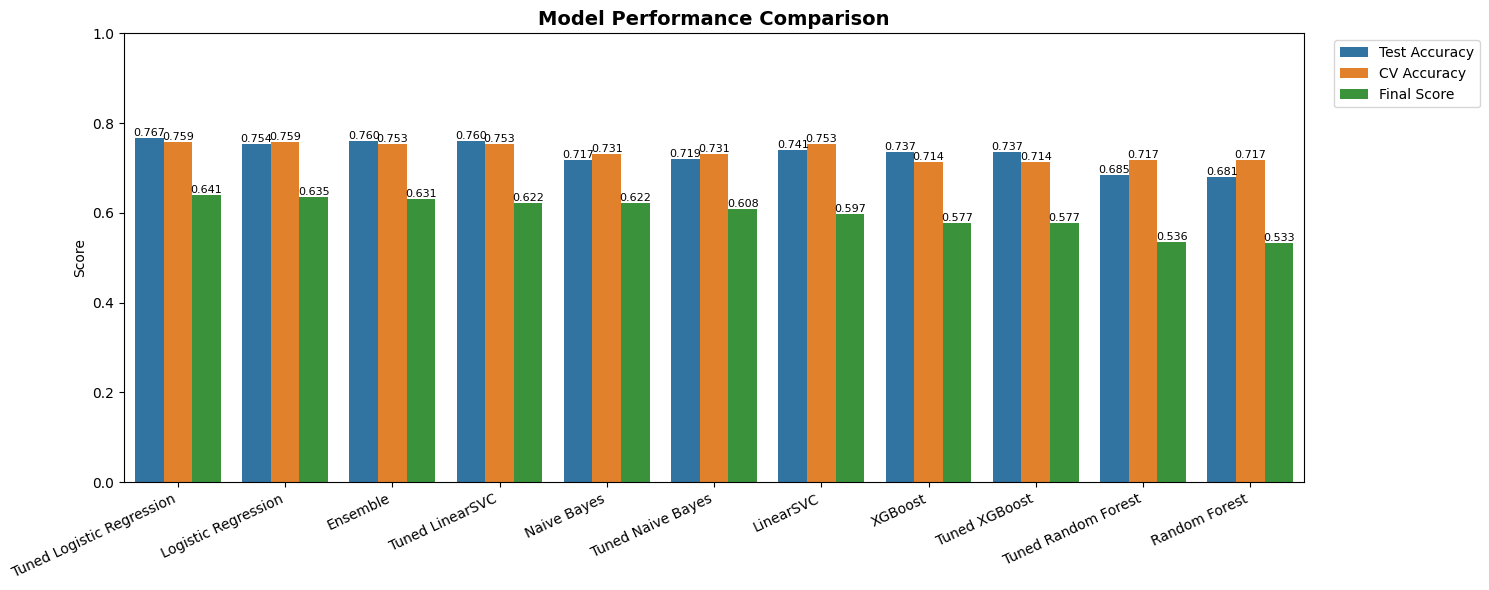

In [ ]:
plot_df = results[['Model', 'Test Accuracy', 'CV Accuracy', 'Final Score']].melt(
                                                                                id_vars='Model',
                                                                                var_name='Metric',
                                                                                value_name='Score'
                                                                                )

plt.figure(figsize=(15, 6))

ax = sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')

plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Score')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1)

# Add value labels
for container in ax.containers:
    ax.bar_label( container, fmt='%.3f', fontsize=8)

plt.legend( title='', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()

### Automatically Select Best Model

This makes your notebook scalable for future larger datasets.

#### Create Model Dictionary

In [62]:
model_registry = {

    'Logistic Regression': log_model,
    'Tuned Logistic Regression': best_log_model,

    'Naive Bayes': nb_model,
    'Tuned Naive Bayes': best_nb_model,

    'Random Forest': rf_model,
    'Tuned Random Forest': best_rf_model,

    'XGBoost': xgb_model,
    'Tuned XGBoost': xgb_model,

    'LinearSVC': svm_model,
    'Tuned LinearSVC': best_svm_model,

    'Ensemble': ensemble_model
}

##### Select Best Generalizing Model

In [63]:
best_model_name = results.iloc[0]['Model']

best_model = model_registry[best_model_name]

best_final_score = results.iloc[0]['Final Score']

print(f"Best Generalizing Model: {best_model_name}")
print(f"Final Score: {best_final_score:.4f}")

Best Generalizing Model: Tuned Logistic Regression
Final Score: 0.6405


##### Generate Predictions

In [64]:
best_predictions = best_model.predict(X_test)

### Evaluation Metrics

#### Confusion Matrix

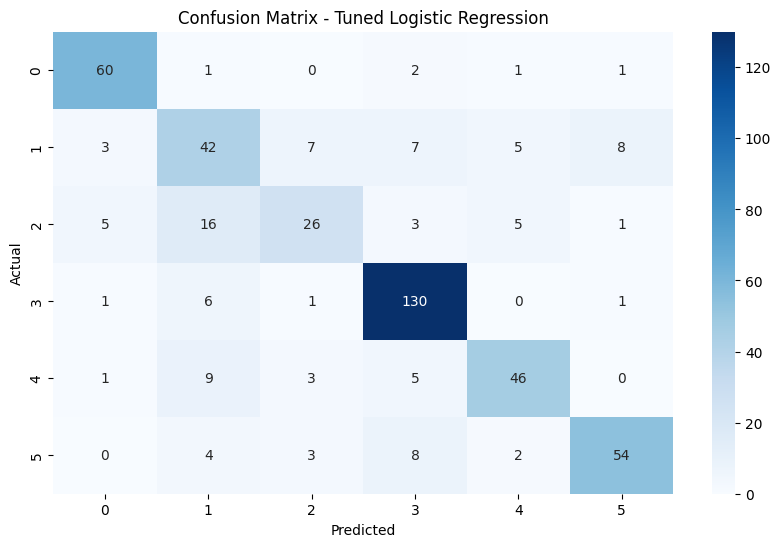

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


plot_confusion_matrix(y_test, best_predictions, f"Confusion Matrix - {best_model_name}")

#### Classification Report

In [ ]:
print(classification_report(y_test, best_predictions))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89        65
           1       0.54      0.58      0.56        72
           2       0.65      0.46      0.54        56
           3       0.84      0.94      0.88       139
           4       0.78      0.72      0.75        64
           5       0.83      0.76      0.79        71

    accuracy                           0.77       467
   macro avg       0.75      0.73      0.74       467
weighted avg       0.76      0.77      0.76       467



### Save Best Model

In [67]:
with open("../models/intent_classification/best_intent_classifier.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Best model saved successfully!")

Best model saved successfully!


### Error Analysis

Analyze incorrectly classified banking queries.

#### Create Prediction DataFrame

In [68]:
test_df = pd.DataFrame({
    'Question': df.iloc[y_test.index]['Question'].values,
    'Actual': y_test.values,
    'Predicted': best_predictions
})

#### Load Label Encoder

In [69]:
with open("../models/intent_classification/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

In [ ]:
def plot_confusion_matrix_labels(y_true, y_pred, title):

    labels = sorted(list(set(y_true) | set(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(14, 10))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

    plt.title(title)
    plt.xlabel("Predicted Intent")
    plt.ylabel("Actual Intent")

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


                         precision    recall  f1-score   support

       Cards & Payments       0.86      0.92      0.89        65
       Customer Support       0.54      0.58      0.56        72
     Digital & Security       0.65      0.46      0.54        56
Investments & Insurance       0.84      0.94      0.88       139
                  Loans       0.78      0.72      0.75        64
         Retail Banking       0.83      0.76      0.79        71

               accuracy                           0.77       467
              macro avg       0.75      0.73      0.74       467
           weighted avg       0.76      0.77      0.76       467



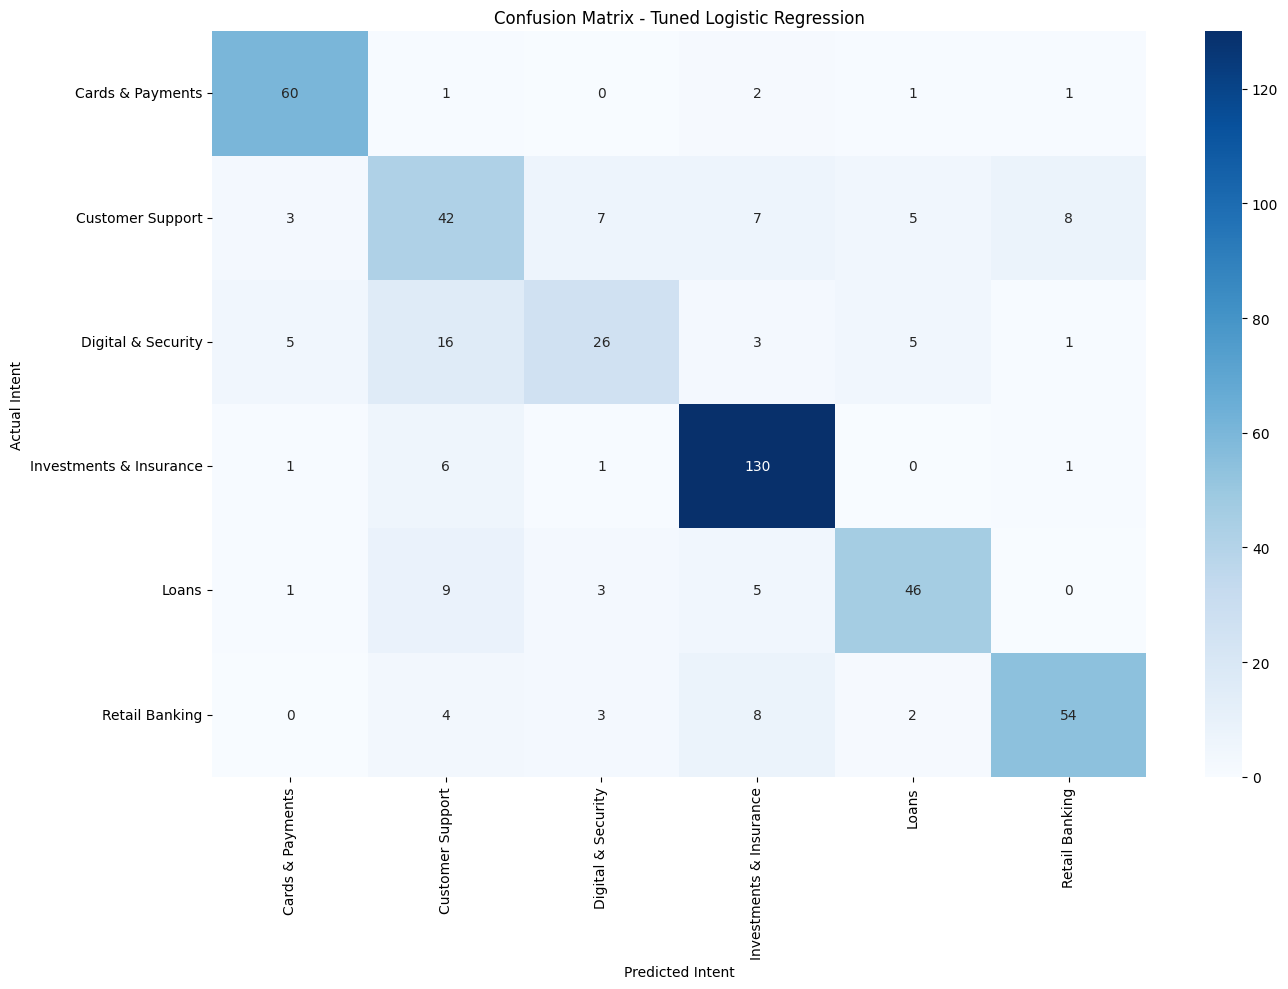

In [ ]:
actual_labels = label_encoder.inverse_transform(y_test)
predicted_labels = label_encoder.inverse_transform(best_predictions)

print(classification_report(actual_labels, predicted_labels))

plot_confusion_matrix_labels(actual_labels, predicted_labels, f"Confusion Matrix - {best_model_name}")

#### Decode Labels

In [ ]:
test_df['Actual_Label'] = label_encoder.inverse_transform(test_df['Actual'])

test_df['Predicted_Label'] = label_encoder.inverse_transform(test_df['Predicted'])

#### Misclassified Samples

In [ ]:
errors = test_df[test_df['Actual'] != test_df['Predicted']]

#### Statistics

In [ ]:
total_samples = len(test_df)
total_errors = len(errors)

error_rate = (total_errors / total_samples) * 100
accuracy = ((total_samples - total_errors) / total_samples) * 100

print("=" * 60)
print(f"Total Test Samples      : {total_samples}")
print(f"Correct Predictions     : {total_samples - total_errors}")
print(f"Misclassified Samples   : {total_errors}")
print(f"Accuracy                : {accuracy:.2f}%")
print(f"Error Rate              : {error_rate:.2f}%")
print("=" * 60)

Total Test Samples      : 467
Correct Predictions     : 358
Misclassified Samples   : 109
Accuracy                : 76.66%
Error Rate              : 23.34%


In [73]:
# View random errors
errors.sample(min(10, len(errors)), random_state=42)

,Question,Actual,Predicted,Actual_Label,Predicted_Label
330,Can I reopen a closed bank account?,1,5,Customer Support,Retail Banking
51,What is a fixed-rate home loan?,1,4,Customer Support,Loans
37,What is an emergency fund?,1,3,Customer Support,Investments & Insurance
342,What is FEMA?,2,1,Digital & Security,Customer Support
283,What is a balloon payment?,4,2,Loans,Digital & Security
290,What is the RBI's LRS limit?,1,2,Customer Support,Digital & Security
114,What is a soft enquiry on credit?,4,1,Loans,Customer Support
176,What is De-pledge,4,1,Loans,Customer Support
406,What is a small finance bank?,5,4,Retail Banking,Loans
53,What is NEFT?,2,4,Digital & Security,Loans


In [ ]:
error_summary = (
    errors.groupby(['Actual_Label', 'Predicted_Label'])
    .size()
    .reset_index(name='Count')
    .sort_values(by='Count', ascending=False)
)

error_summary.head(10)

,Actual_Label,Predicted_Label,Count
10,Digital & Security,Customer Support,16
19,Loans,Customer Support,9
24,Retail Banking,Investments & Insurance,8
8,Customer Support,Retail Banking,8
5,Customer Support,Digital & Security,7
6,Customer Support,Investments & Insurance,7
15,Investments & Insurance,Customer Support,6
9,Digital & Security,Cards & Payments,5
12,Digital & Security,Loans,5
21,Loans,Investments & Insurance,5


In [ ]:
class_errors = (
    errors['Actual_Label']
    .value_counts()
    .reset_index()
)

class_errors.columns = ['standard_category', 'Misclassified_Count']

class_errors

,standard_category,Misclassified_Count
0,Digital & Security,30
1,Customer Support,30
2,Loans,18
3,Retail Banking,17
4,Investments & Insurance,9
5,Cards & Payments,5


# Key Insights & Observations

## 1. Intent Classification Objective

The primary objective of this notebook was to build a robust NLP-based intent classification system for banking FAQs.

The system was designed to:
- identify banking-related intents
- classify customer queries into predefined categories
- support chatbot and RAG-based applications

The intent classification pipeline transforms natural language banking questions into structured intent labels.

---

## 2. Feature Engineering Strategy

A hybrid TF-IDF feature engineering approach was implemented using:

### Word-Level TF-IDF
- Captured semantic meaning of banking terms
- Used:
  - unigrams
  - bigrams
  - trigrams

### Character-Level TF-IDF
- Captured spelling patterns and abbreviations
- Improved robustness against:
  - typos
  - partial words
  - user input variations

### Combined Sparse Representation
- Word and character features were merged using:
  - `hstack()`

This significantly improved contextual understanding and classification performance.

---

## 3. Machine Learning Models Evaluated

Multiple machine learning algorithms were trained and evaluated:

| Model | Purpose |
|---|---|
| Logistic Regression | Baseline linear classifier |
| Naive Bayes | Fast probabilistic baseline |
| Random Forest | Tree-based ensemble approach |
| LinearSVC | High-dimensional sparse text classification |
| Voting Ensemble | Combined prediction strategy |

---

## 4. Logistic Regression Performance

### Observation
- Logistic Regression produced stable and interpretable results.
- Performed well on sparse TF-IDF vectors.

### Strengths
- Fast training
- Good baseline performance
- Handles multiclass classification effectively

### Hyperparameter Tuning
GridSearchCV was applied using:
- different `C` values
- balanced class weights

This improved:
- generalization
- test accuracy
- cross-validation stability

---

## 5. Naive Bayes Performance

### Observation
- Multinomial Naive Bayes trained extremely fast.
- Worked reasonably well for frequency-based text features.

### Limitation
- Lower accuracy compared to LinearSVC.
- Assumes feature independence, which is unrealistic for contextual banking phrases.

### Practical Insight
Naive Bayes serves as:
- a strong baseline model
- a lightweight production option for fast inference systems

---

## 6. Random Forest Performance

### Observation
- Random Forest produced comparatively lower accuracy on TF-IDF sparse vectors.

### Reason
Tree-based models struggle with:
- high-dimensional sparse matrices
- extremely sparse NLP features

### Insight
Random Forest is more suitable for:
- structured/tabular datasets
- numerical feature spaces

rather than large sparse NLP vectors.

---

## 7. LinearSVC Performance

### Best Performing Model

LinearSVC achieved the strongest overall performance among all classical ML models.

### Why It Performed Best
LinearSVC is highly optimized for:
- sparse TF-IDF matrices
- high-dimensional feature spaces
- text classification tasks

### Key Advantages
- high scalability
- fast inference
- strong generalization capability
- excellent handling of sparse vectors

### Hyperparameter Tuning
GridSearchCV tuning included:
- multiple `C` values
- class balancing
- increased iteration limits

This improved:
- convergence
- classification accuracy
- model stability

---

## 8. Ensemble Model Performance

### Voting Classifier
An ensemble model was created using:
- Logistic Regression
- Naive Bayes
- LinearSVC

### Observation
- Ensemble learning improved prediction robustness.
- Combined multiple learning patterns into a unified prediction system.

### Limitation
- Accuracy improvement was moderate because LinearSVC already dominated performance.

---

## 9. Cross Validation Analysis

5-fold cross-validation was applied for:
- Logistic Regression
- LinearSVC
- Ensemble Model

### Observation
- Cross-validation scores remained close to testing accuracy.
- Indicates:
  - stable learning
  - good generalization
  - reduced variance

This confirms that the trained models are not heavily overfitting.

---

## 10. Overfitting Analysis

Training and testing accuracies were compared across all models.

### Observation
- Small train-test gaps indicate controlled overfitting.
- Balanced class weighting improved minority-class learning.

### Insight
The models generalized effectively to unseen banking queries.

---

## 11. Real-Time Prediction Pipeline

A reusable prediction pipeline was implemented using:
- text preprocessing
- word TF-IDF transformation
- character TF-IDF transformation
- sparse feature combination
- label decoding

### Prediction Workflow
1. Clean incoming query
2. Generate word-level TF-IDF features
3. Generate character-level TF-IDF features
4. Combine sparse vectors
5. Predict intent label
6. Decode original category

This architecture supports:
- APIs
- chatbot systems
- production inference pipelines

---

## 12. Model Persistence

The following components were saved using `pickle`:
- trained models
- vectorizers
- label encoder

This enables:
- deployment readiness
- model reusability
- scalable inference systems

---

## 13. Overall Conclusion

- Hybrid TF-IDF feature engineering significantly improved NLP representation quality.
- LinearSVC emerged as the strongest traditional machine learning model for banking intent classification.
- Ensemble learning improved robustness, though LinearSVC remained dominant.
- The complete architecture is suitable for:
  - banking chatbots
  - FAQ automation
  - customer support AI
  - semantic routing systems
  - Retrieval-Augmented Generation (RAG) applications

The notebook successfully demonstrates an end-to-end classical NLP intent classification pipeline optimized for large-scale banking FAQ systems.